In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# We first concatenate daymet data for individual grid cells into a DataArray file

In [3]:
lon_list = np.arange(-73.7,-73,0.01)
lat_list = np.arange(41.3,42.7,0.01)

annual_mean_precip_daymet = xr.DataArray(np.full([len(lat_list),len(lon_list),12],np.NaN),
                                         dims=['lat','lon','month'],
                                         coords = {'lat':lat_list,
                                                   'lon':lon_list,
                                                   'month':np.arange(1,13)})

annual_mean_airt_daymet = xr.DataArray(np.full([len(lat_list),len(lon_list),12],np.NaN),
                                         dims=['lat','lon','month'],
                                         coords = {'lat':lat_list,
                                                   'lon':lon_list,
                                                   'month':np.arange(1,13)})

for ilat,latitude in enumerate(lat_list):
    for ilon, longitude in enumerate(lon_list):
        fname = "daymet_grid/"+"daymet.%s_%s.csv"%("%0.2f"%(latitude),
                                                  "%0.2f"%(longitude))
        df_daymet_grid = pd.read_csv(fname)
        annual_mean_precip_daymet[ilat,ilon,:] = df_daymet_grid['prcp_mm_month'].values
        annual_mean_airt_daymet[ilat,ilon,:]   = df_daymet_grid['tair_deg_C'].values

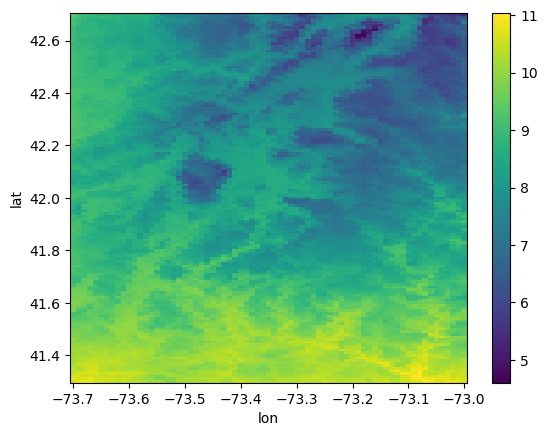

In [4]:
annual_mean_airt_daymet.mean(dim='month').plot()

# read in our model input data

In [5]:
month_precip_era5 = []
month_airt_era5 = []
for year in range(1990,2006):
    ds_era5_met = xr.open_dataset('regrid/ERA5.01205500.regrid.%s.nc'%year)
    month_precip = ds_era5_met.MTPR.resample({'time':"MS"}).sum()
    month_precip_era5.append(month_precip)
    month_airt = ds_era5_met.VAR_2T.resample({'time':"MS"}).mean()
    month_airt_era5.append(month_airt)

In [6]:
mean_month_precip = xr.concat(month_precip_era5, dim='time')
mean_month_airt = xr.concat(month_airt_era5,dim='time')

In [7]:
multiyear_mean_month_precip = mean_month_precip.groupby(mean_month_precip.time.dt.month).mean()
multiyear_mean_month_airt = mean_month_airt.groupby(mean_month_airt.time.dt.month).mean()

# compare them side by side

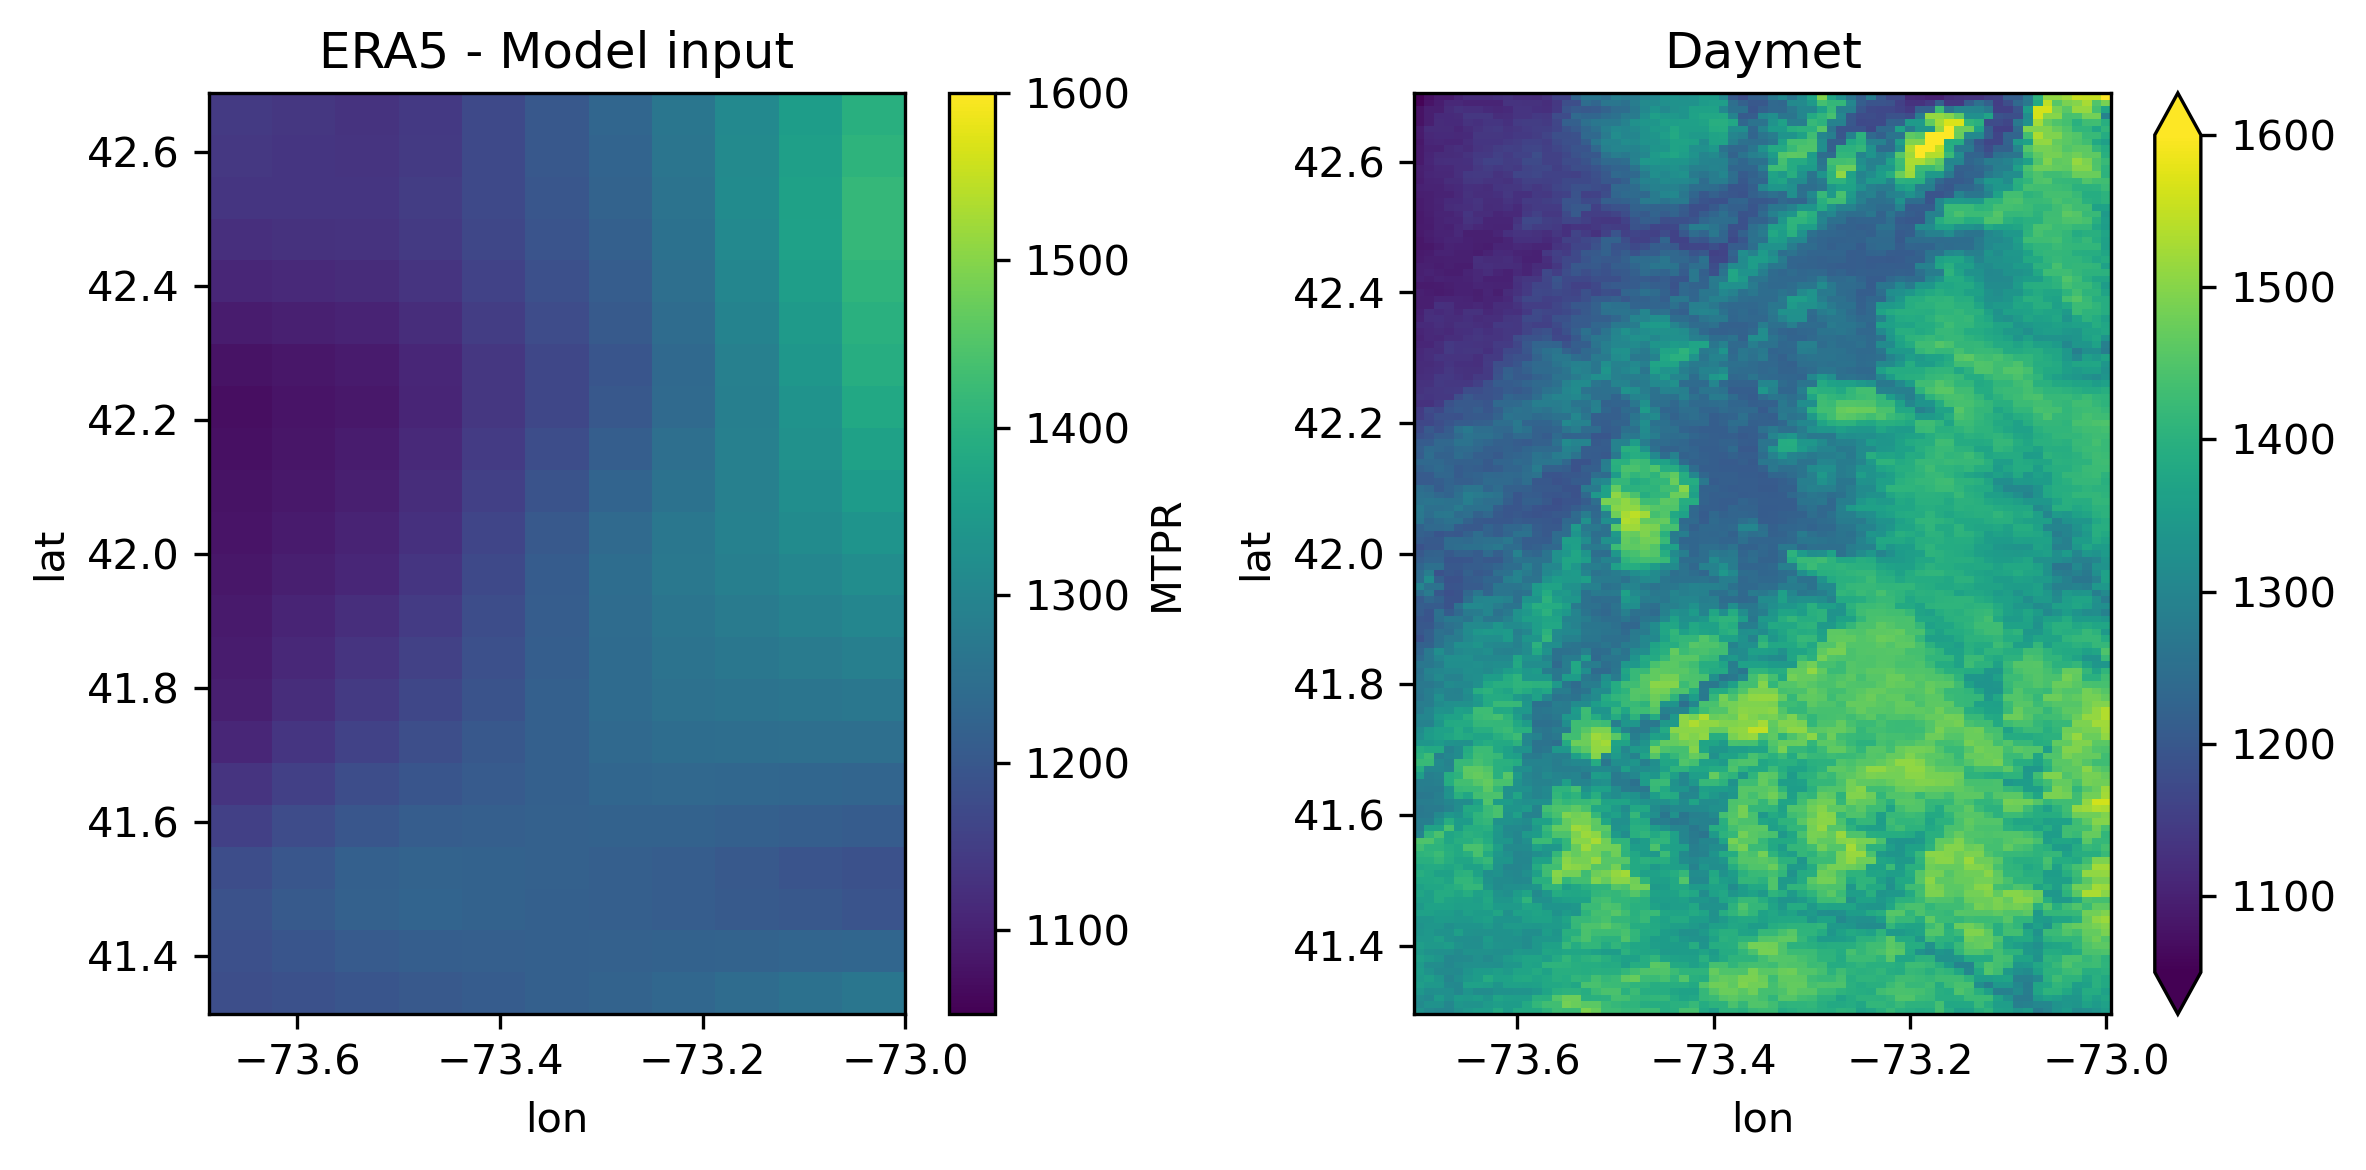

In [8]:
fig,ax = plt.subplots(1,2,figsize=[8,4],dpi=300)
multiyear_mean_month_precip.sum(dim='month').plot(ax=ax[0],vmax=1600,vmin=1050)
annual_mean_precip_daymet.sum(dim='month').plot(ax=ax[1],vmax=1600,vmin=1050)

ax[0].set_title("ERA5 - Model input")
ax[1].set_title("Daymet")

fig.tight_layout()

# regrid the daymet data to ERA5 grids so that we can calculate their differences

In [9]:
import xesmf as xe

In [10]:
regridder = xe.Regridder(annual_mean_precip_daymet,
                         multiyear_mean_month_precip,
                         method = 'bilinear')

In [11]:
annual_mean_precip_daymet_regrid = regridder(annual_mean_precip_daymet)

/home/jovyan/data/conda-envs/xesmf_env/lib/python3.11/site-packages/xesmf/smm.py:130: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


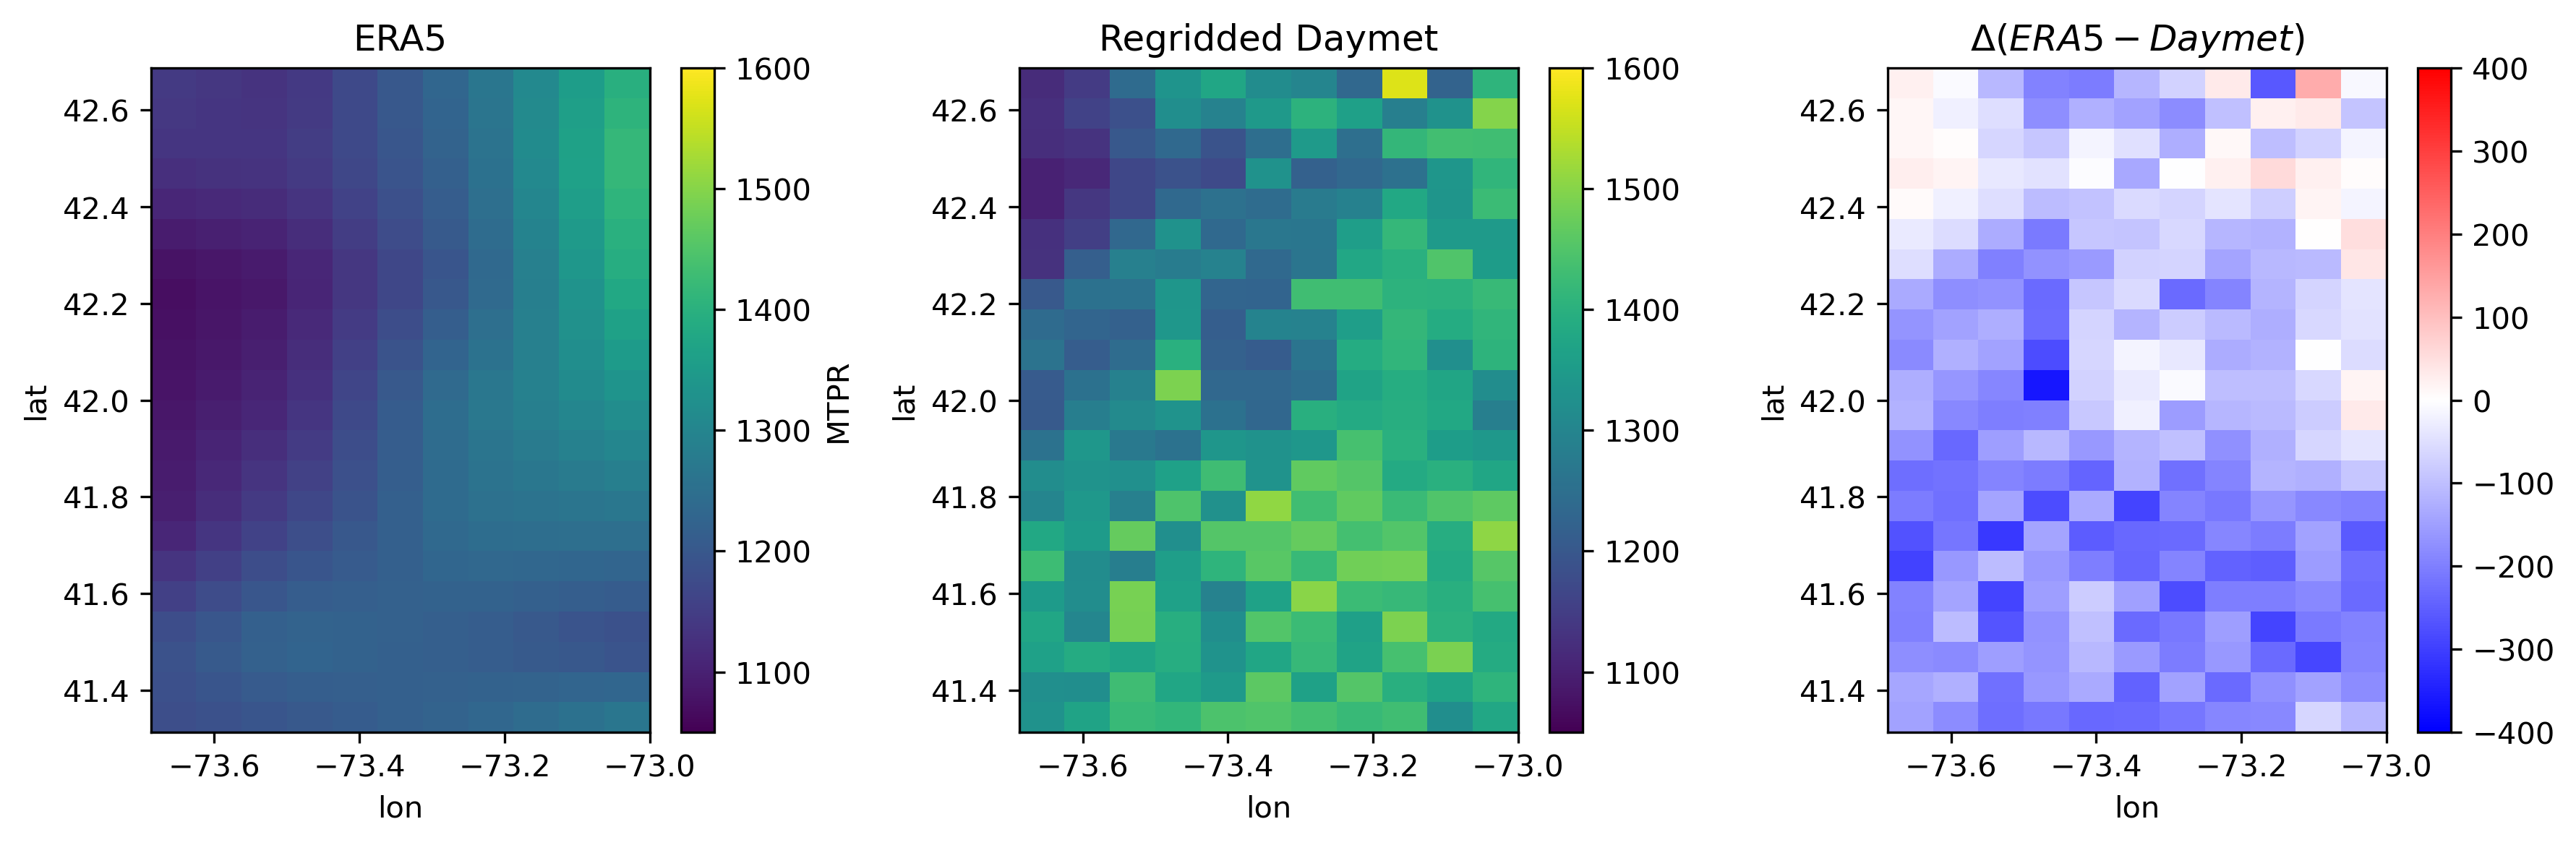

In [12]:
mean_annual_daymet = annual_mean_precip_daymet_regrid.sum(dim='month')
mean_annual_era5 = multiyear_mean_month_precip.sum(dim='month')

fig,ax = plt.subplots(1,3,figsize=[12,4],dpi=300)
mean_annual_era5.plot(ax=ax[0],vmax=1600,vmin=1050)
mean_annual_daymet.plot(ax=ax[1],vmax=1600,vmin=1050)
(mean_annual_era5 - mean_annual_daymet).plot(ax=ax[2],vmax=400,vmin=-400,cmap='bwr')

ax[0].set_title("ERA5")
ax[1].set_title("Regridded Daymet")
ax[2].set_title(r"$\Delta(ERA5 - Daymet)$")
fig.tight_layout()

In [13]:
annual_mean_airt_daymet_regrid = regridder(annual_mean_airt_daymet)

/home/jovyan/data/conda-envs/xesmf_env/lib/python3.11/site-packages/xesmf/smm.py:130: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


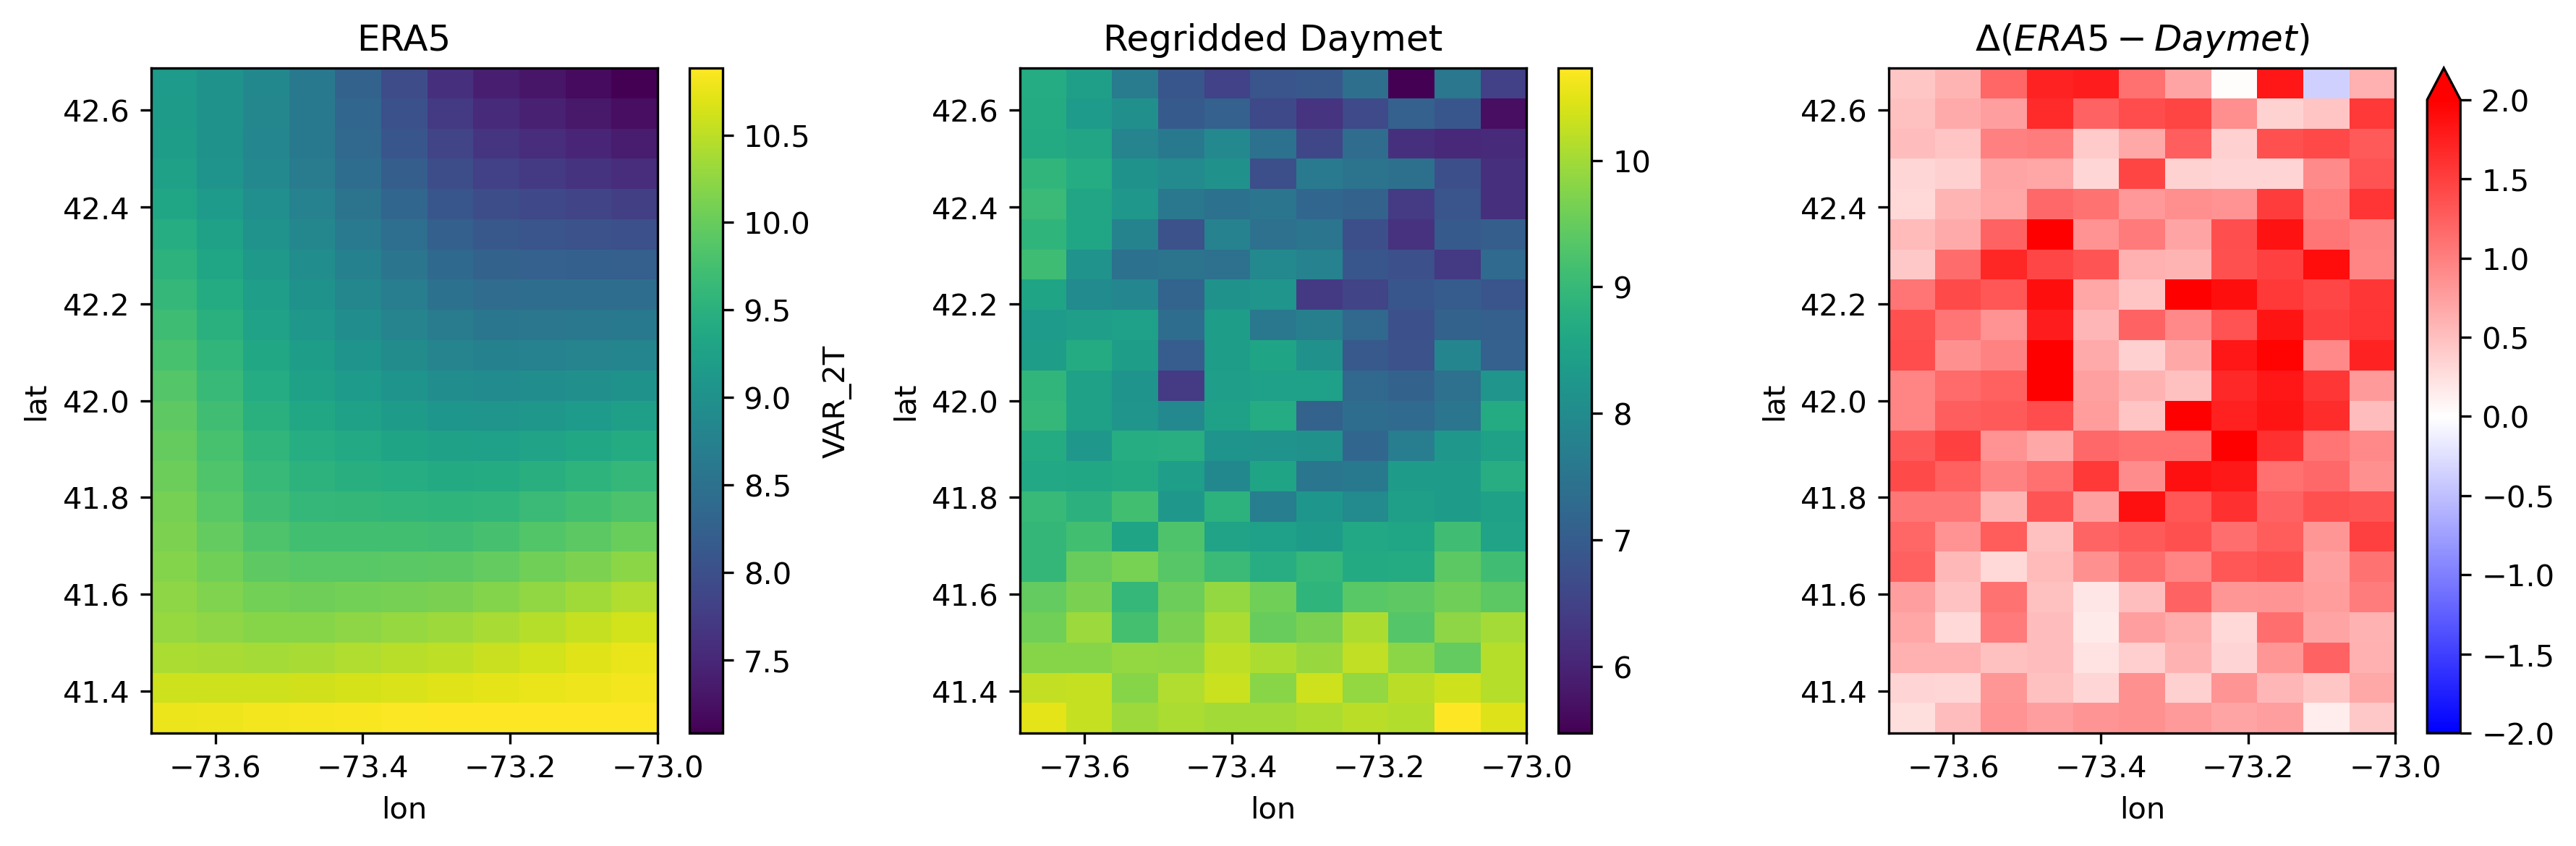

In [15]:
mean_annual_daymet_t = annual_mean_airt_daymet_regrid.mean(dim='month')
mean_annual_era5_t = multiyear_mean_month_airt.mean(dim='month')

fig,ax = plt.subplots(1,3,figsize=[12,4],dpi=300)

    
mean_annual_era5_t.plot(ax=ax[0])
mean_annual_daymet_t.plot(ax=ax[1])
(mean_annual_era5_t - mean_annual_daymet_t).plot(ax=ax[2],vmax=2,vmin=-2,cmap='bwr')

ax[0].set_title("ERA5")
ax[1].set_title("Regridded Daymet")
ax[2].set_title(r"$\Delta(ERA5 - Daymet)$")
fig.tight_layout()

In [16]:
import calendar

# Can we check the biases in monthly air temperature?

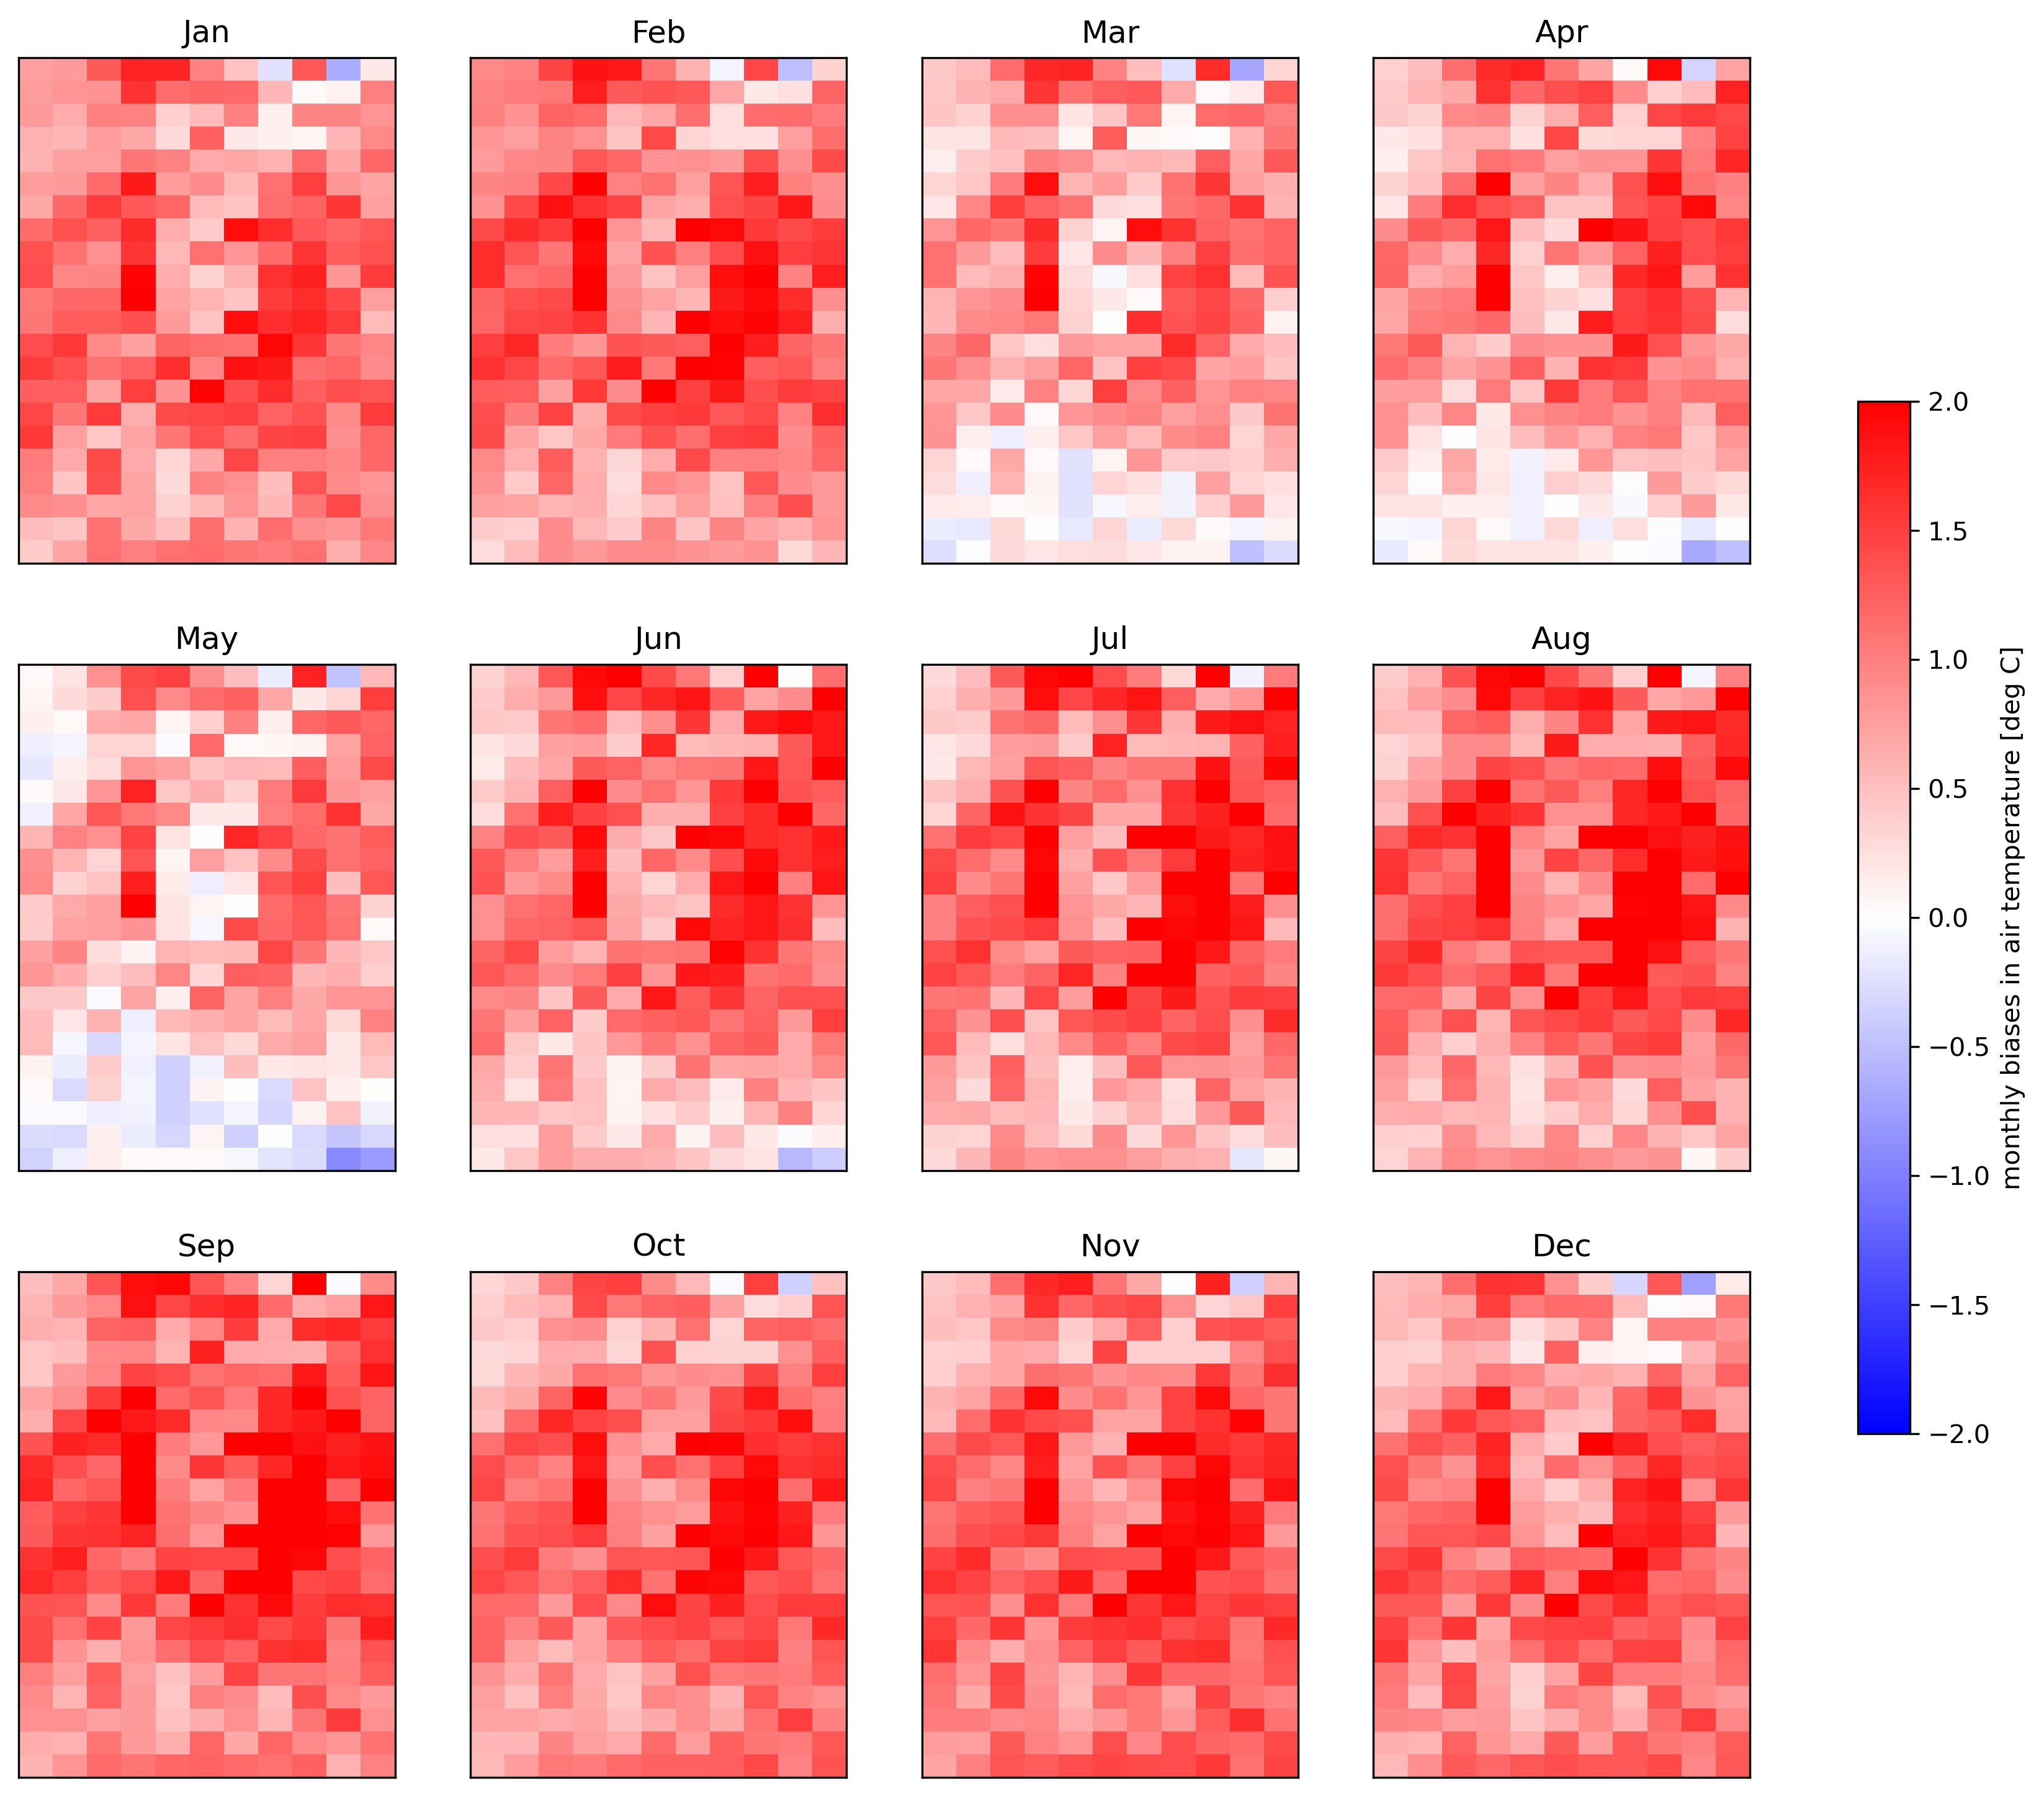

In [17]:
fig,ax = plt.subplots(3,4,figsize=[15,12],dpi=300)

for i,month in enumerate(np.arange(1,13)):
    c = int(i%4)
    r = int(np.floor(i/4))
    daymet_t_month = annual_mean_airt_daymet_regrid.sel(month=month)
    era5_t_month = multiyear_mean_month_airt.sel(month=month)
    
    pcm = (era5_t_month - daymet_t_month).plot(ax=ax[r,c],vmax=2,vmin=-2,cmap='bwr',
                                         add_colorbar=False)
    ax[r,c].set_title(calendar.month_abbr[month])
    ax[r,c].set_xticks([])
    ax[r,c].set_yticks([])
    ax[r,c].set_xlabel('')
    ax[r,c].set_ylabel('')
    
cb = fig.colorbar(pcm, ax=np.ravel(ax[:,:]), shrink=0.6, orientation="vertical")
cb.set_label("monthly biases in air temperature [deg C]")
# fig.tight_layout()